In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, median_filter

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

np.random.seed(42)

# **Application du modèle de Potts à la restauration d'images : une implémentation basée sur l'article de Storath et al.**

## **Résumé**

Ce notebook est un complément de notre rapport et il est essentiel de clarifier le lien entre cette implémentation et l'article de référence de Storath et al.

L'article original traite du problème général des problèmes inverses ($f = Au + \eta$), incluant :
1.  La reconstruction tomographique (où $A$ est la transformée de Radon).
2.  La déconvolution (où $A$ est un opérateur de flou).
3.  Le débruitage (où $A$ est la matrice identité $I$).

Ce notebook se concentre exclusivement sur le cas du **débruitage** ($A = I$).

**Conséquences sur l'algorithme :**

*   **Le cœur de la méthode (Potts) est identique :** La partie la plus complexe de l'article (la décomposition du problème $L_0$ en sous-problèmes 1D résolus par programmation dynamique) est implémentée fidèlement. C'est le moteur de la régularisation.

*   **Le terme d'attache aux données est simplifié :** Dans l'article, la mise à jour de l'image intermédiaire $v$ nécessite la résolution d'un système linéaire complexe ($A^*A + \mu I$). Dans notre cas, comme $A=I$, cette étape se simplifie en une moyenne pondérée très rapide à calculer.

Cette approche nous permet d'isoler et d'analyser le comportement unique du **modèle de Potts** (sa capacité à créer des images constantes par morceaux) sans la lourdeur computationnelle de la reconstruction tomographique.
En effet dans cette situation, l'opérateur $A$ est la transformée de Radon. C'est un problème inverse plus complexe, car il faut "défaire" la transformation en plus de gérer le bruit.

 Nous abordons le problème du **débruitage**, un cas fondamental de problème inverse, en exploitant l'a priori que les images d'intérêt sont **constantes par morceaux**. Après avoir posé le cadre mathématique du modèle, nous détaillons deux algorithmes de résolution : une approximation simple par traitement alterné, et l'implémentation plus rigoureuse de la méthode ADMM avec une discrétisation isotrope. Les performances sont évaluées sur des images synthétiques (fantôme de Shepp-Logan) et réelles (scanner CT cérébral).

## **1. Introduction : Problèmes inverses et évaluation de la qualité**

### **1.1. Le cadre des problèmes inverses**

En traitement d'images, de nombreux problèmes se formulent comme la résolution d'une équation de la forme :
$$ f = Au + \eta $$
où $f$ représente les données observées (bruitées, indirectes), $u$ l'image "propre" que l'on cherche, $A$ un opérateur linéaire modélisant l'acquisition, et $\eta$ un bruit. Ces problèmes sont typiquement **mal-posés** au sens de Hadamard : la solution peut ne pas exister, ne pas être unique, ou ne pas dépendre continûment des données. C'est cette dernière instabilité qui nous préoccupe : un bruit infime $\eta$ peut rendre la solution $A⁻¹f$ inutilisable.

La solution est de reformuler le problème en un problème d'optimisation variationnelle avec **régularisation** :
$$ u^* = \arg\min_u \left\{ \|Au - f\|_2^2 + \gamma R(u) \right\} $$
- **Terme de fidélité ($\|Au - f\|_2^2$) :** Assure que la solution reste cohérente avec les données.
- **Terme de régularisation ($R(u)$) :** Incorpore un a priori sur la solution $u$ pour la stabiliser.

Comme dit plus haut, nous nous concentrerons sur le cas spécifique du **débruitage**. Dans ce scénario, l'opérateur $A$ est l'identité ($A=I$), et le problème revient à trouver l'image $u$ la plus proche de $f$ tout en respectant la régularisation.

### **1.2. Critères d'évaluation : Comment mesurer la "qualité" ?**

Pour évaluer la performance des algorithmes, nous utilisons des critères quantitatifs et qualitatifs.

#### **Critères quantitatifs** :
Nous utilisons deux métriques standards basées sur l'erreur entre l'image reconstruite $u$ et la vérité terrain `u_vrai`.

1.  **Erreur quadratique moyenne (MSE - Mean Squared Error) :**
    $$ \text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (u_i - (u_{\text{vrai}})_i)^2 $$
    Elle mesure l'erreur moyenne au carré. **Un MSE plus faible est meilleur.**

2.  **Rapport signal sur bruit (PSNR - Peak Signal-to-Noise Ratio) :**
    $$ \text{PSNR} = 10 \log_{10} \left( \frac{\text{MAX}_I^2}{\text{MSE}} \right) $$
    où `MAX_I` est la valeur maximale possible d'un pixel (par exemple, 1.0 pour nos images normalisées). Le PSNR est exprimé en décibels (dB). Il mesure le rapport entre la puissance maximale du signal et la puissance de l'erreur. **Un PSNR plus élevé est meilleur.** C'est la métrique la plus couramment utilisée pour comparer les algorithmes de restauration.

#### **Critère qualitatif** :
L'**analyse visuelle** reste indispensable. Une image peut avoir un bon PSNR mais présenter des artefacts désagréables à l'œil (flou, contours en escalier). Nous jugerons donc la qualité de la suppression du bruit, la netteté des contours et l'absence d'artefacts.


#### **Ajouter du bruit**

C'est ce qu'on appelle un **"problème inverse synthétique"**.

Cette démarche remplit trois fonctions essentielles :

Dans la vraie vie (par exemple, une image médicale sortant d'un scanner), nous n'avons accès qu'à l'image bruitée $f$. Nous ne connaissons jamais l'image parfaite $u$.

*   Si nous testions l'algorithme directement sur une vraie radio, nous obtiendrions une image "nettoyée", mais **il serait impossible de savoir si elle est juste**. Est-ce que ce petit point blanc que l'algorithme a effacé était du bruit ou une tumeur débutante ? Impossible à dire. Il nous faut donc **une "vérité terrain" (ground truth)** :     

*   En partant d'un signal propre connu (la ligne bleue que vous verrez plus bas) et en ajoutant nous-mêmes le bruit, nous pourrons **comparer les résultats de l'algorithme avec ceux attendus** en utilisant notamment les métriques définies plus haut.

* **tester les limites de l'algorithme** : "Que se passe-t-il si le bruit est énorme ($\sigma=0.5$) ?" On peut observer à quel moment l'algorithme "casse" et commence à halluciner des segments.

Il est à noter que l'article simule un bruit gaussien.
C'est le modèle standard en traitement du signal car il modélise bien le "bruit thermique" des capteurs électroniques. Mathématiquement, l'utilisation de la norme $L_2$ (l'erreur au carré $\|Au-f\|^2$) dans notre fonctionnelle de coût (avec $A=I$ ici) est justifiée **si et seulement si** le bruit est gaussien. Dans ce cas, minimiser l'erreur quadratique revient à maximiser la probabilité (vraisemblance) de la solution.




### **2. Le modèle de Potts : Formalisme mathématique**

Le modèle de Potts utilise une régularisation basée sur la (pseudo-)norme $L₀$ du gradient, qui pénalise la présence de discontinuités :
$$
R(u) = \|Du\|_0
$$
La fonctionnelle à minimiser est donc :
$$
u^* = \arg\min_u \left\{ \gamma \|Du\|_0 + \|Au - f\|_2^2 \right\}
$$

*   **Discrétisation et Norme `L₀` :** En discret, l'opérateur de gradient `D` est approché par des différences finies entre pixels voisins. La norme `L₀` compte alors le **nombre de paires de pixels voisins ayant des valeurs différentes**. En minimisant ce nombre, on favorise les solutions composées de grandes régions de couleur uniforme.



La nature non-convexe et non-lisse de la norme $L₀$ rend l'optimisation difficile. L'approche de Storath et al. consiste à décomposer ce problème 2D complexe en une série de sous-problèmes 1D qui admettent une solution exacte.

### **3. Algorithme de résolution : ADMM isotrope**

#### **3.1. Le solveur 1D exact : programmation dynamique**

Dans notre code, le solveur 1D (`min_l2_potts_1d`) utilise la **programmation dynamique**. C'est une méthode algorithmique utilisée pour résoudre des problèmes d'optimisation complexes en les décomposant en sous-problèmes plus simples.

**Le principe : "Ne jamais calculer la même chose deux fois."**

Au lieu d'essayer toutes les combinaisons possibles de segments (ce qui serait exponentiel et impossible à calculer, par exemple $2^N$ combinaisons), l'algorithme procède de manière itérative de gauche à droite :

1.  **Décomposition :** Pour trouver la meilleure segmentation s'arrêtant au pixel $j$, on regarde toutes les positions possibles $i$ (où $i < j$) où le dernier segment aurait pu commencer.

2.  **Mémorisation :** On utilise le résultat optimal déjà calculé pour le pixel $i$ (stocké en mémoire) et on y ajoute le coût du nouveau segment de $i$ à $j$ + la pénalité de saut $\gamma$.

3.  **Choix optimal :** On garde seulement le $i$ qui donne le coût total minimal pour arriver à $j$.

**Résultat :** Cela réduit la complexité du problème (d'ordre $2^N$ qui est le nombre de combinaisons possibles avec $N$ la longueur du signal $1D$) à $O(N^2)$ (quadratique). C'est ce qui garantit que notre solution 1D est exacte et non une simple approximation.


In [3]:
# Algorithme de programmation dynamique pour Potts 1D
# C'est le cœur de l'algorithme, utilisé comme sous-problème dans les cas 2D.
def min_l2_potts_1d(f: np.ndarray, gamma: float) -> np.ndarray:
    """minimise le problème de Potts L2 en 1D par programmation dynamique."""
    n = len(f)
    if n == 0:
        return np.array([])

    cumsum_f = np.insert(np.cumsum(f), 0, 0)
    cumsum_f2 = np.insert(np.cumsum(f**2), 0, 0)

    B = np.zeros((n + 1, n + 1))
    M = np.zeros(n + 1)
    P = np.zeros(n + 1, dtype=int)

    for i in range(n):
        for j in range(i + 1, n + 1):
            segment_len = j - i
            mean = (cumsum_f[j] - cumsum_f[i]) / segment_len
            cost_l2 = (cumsum_f2[j] - cumsum_f2[i]) - 2 * mean * (cumsum_f[j] - cumsum_f[i]) + segment_len * mean**2
            B[i, j] = cost_l2

    for j in range(1, n + 1):
        M[j] = B[0, j]
        P[j] = 0
        for i in range(1, j):
            cost = M[i] + gamma + B[i, j]
            if cost < M[j]:
                M[j] = cost
                P[j] = i

    u = np.zeros(n)
    j = n
    while j > 0:
        i = P[j]
        if i < j:
            u[i:j] = np.mean(f[i:j])
        j = i

    return u

test de l'algorithme sur un signal 1D


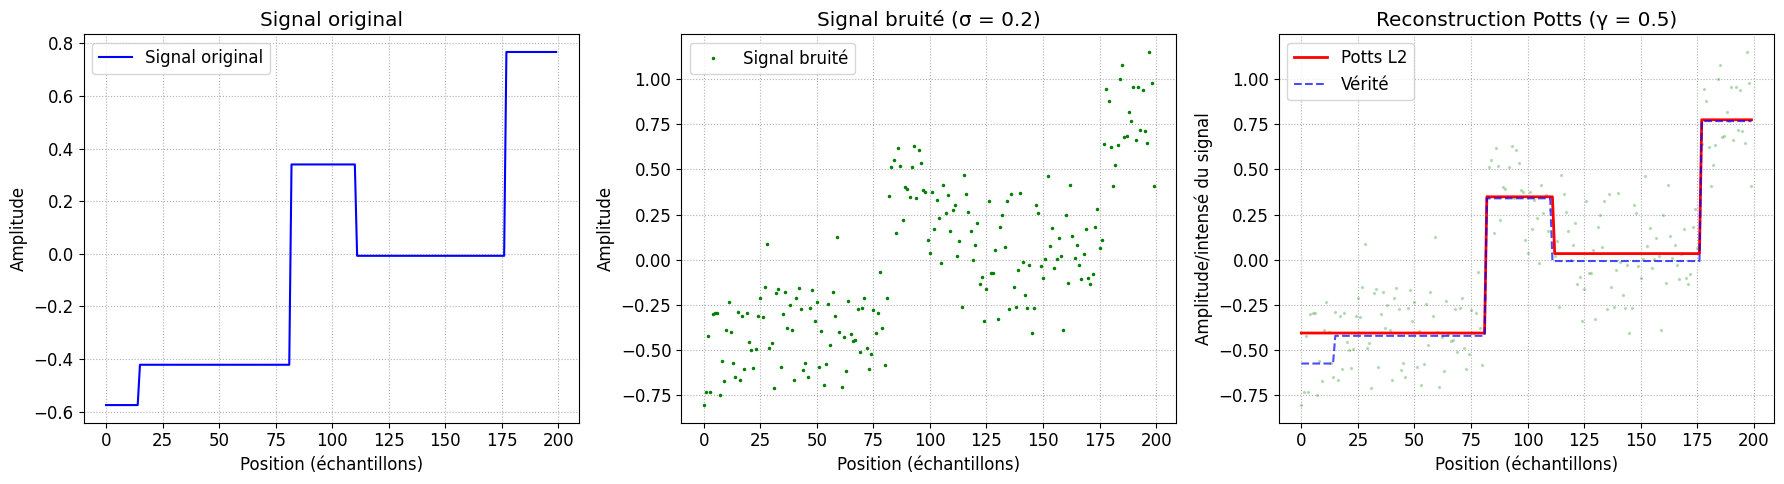

In [4]:
# test sur signal 1D avec bruit gaussien

def create_piecewise_constant_signal(n: int = 200, n_segments: int = 5) -> np.ndarray: # annotation de ce que la fonction doit exactement retourner
    """crée un signal constant par morceaux."""
    signal = np.zeros(n)
    segment_positions = np.sort(np.random.choice(n - 1, n_segments - 1, replace=False))
    segment_positions = np.concatenate(([0], segment_positions, [n]))
    for i in range(len(segment_positions) - 1):
        start, end = segment_positions[i], segment_positions[i+1]
        signal[start:end] = np.random.randn()
    return signal

print("test de l'algorithme sur un signal 1D")

n = 200
true_signal = create_piecewise_constant_signal(n, n_segments=5)
noise_level = 0.2
noisy_signal = true_signal + noise_level * np.random.randn(n)
gamma_1d = 0.5
denoised_signal = min_l2_potts_1d(noisy_signal, gamma_1d)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# graphe 1: signal original
axes[0].plot(true_signal, 'b-', label='Signal original')
axes[0].set_title('Signal original')
axes[0].set_xlabel('Position (échantillons)')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(True, linestyle=':')

# graphe 2: signal bruité
axes[1].plot(noisy_signal, 'g.', markersize=3, label='Signal bruité')
axes[1].set_title(f'Signal bruité (σ = {noise_level})')
axes[1].set_xlabel('Position (échantillons)')
axes[1].set_ylabel('Amplitude')
axes[1].legend()
axes[1].grid(True, linestyle=':')

# graphe 3 : reconstruction
axes[2].plot(noisy_signal, 'g.', markersize=3, alpha=0.2) # Bruit en fond
axes[2].plot(denoised_signal, 'r-', label='Potts L2', linewidth=2)
axes[2].plot(true_signal, 'b--', alpha=0.7, label='Vérité')
axes[2].set_title(f'Reconstruction Potts (γ = {gamma_1d})')
axes[2].set_xlabel('Position (échantillons)')
axes[2].set_ylabel('Amplitude/intensé du signal')
axes[2].legend()
axes[2].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

### **3.2. Analyse détaillée du cas 1D**

Ce test préliminaire sur un signal unidimensionnel est crucial. Il sert à valider que notre "brique de base" (le solveur exact par programmation dynamique) fonctionne correctement avant de l'intégrer dans l'algorithme 2D complexe.

Voici comment interpréter les trois graphiques ci-dessus :

#### **1. Le signal original (graphique de gauche - ligne bleue)**

Ce graphique représente la **vérité terrain** ($u_{\text{vrai}}$).
*   C'est le signal idéal que nous cherchons à retrouver.
*   **Caractéristique clé :** Il est **constant par morceaux**. Cela signifie qu'il est composé de **segments plats horizontaux** séparés par des **sauts brusques (discontinuités)**. C'est exactement le type de signal pour lequel le modèle de Potts est conçu.

#### **2. Le signal bruité (graphique central - points verts)**

C'est le signal "observé" ($f$), c'est-à-dire l'entrée de notre algorithme.
*   Nous avons ajouté un **bruit gaussien** aléatoire au signal original.
*   Le signal n'est plus une ligne continue, mais un nuage de points dispersés.
*   L'ordinateur ne voit que ces points verts. Il ne connait pas la ligne bleue. Il doit "deviner" où sont les sauts et où sont les plats, sans se laisser tromper par la dispersion des points.

#### **3. La reconstruction Potts (graphique de droite)**

C'est le résultat de l'algorithme superposé aux données.
*   **Points verts (fond) :** Les données bruitées.
*   **Pointillés bleus :** La vérité terrain (pour référence).
*   **Ligne rouge solide :** La solution trouvée par notre algorithme ($u^*$).

**Analyse de la performance (ligne rouge) :**

*   **Détection des sauts :** L'algorithme a parfaitement identifié les positions des changements brutaux (par exemple autour de $x=80$ et $x=175$). Il n'a pas créé de "faux sauts" à cause du bruit.

*   **Lissage des plateaux :** Sur chaque segment, la ligne rouge est parfaitement horizontale. L'algorithme a calculé la **moyenne** des points verts de cette section.

*   **Légère déviation (phénomène normal) :** Sur le premier plateau (entre $x = 0$ et $x = 15$ environ), l’algorithme remplace le nuage de points bruités par une seule valeur constante. Cette valeur est simplement **la moyenne des points bruités** sur cette zone. Comme le bruit est aléatoire, parfois la moyenne est un peu trop haute ou un peu trop basse.
Ici, le bruit est **par hasard légèrement positif**, donc la moyenne est légèrement au-dessus de la vraie valeur.


**Conclusion du test :**

Ce résultat valide notre implémentation de la fonction `min_l2_potts_1d`. L'algorithme réussit à transformer un nuage de points bruité en une structure propre, constante par morceaux, en résolvant exactement le compromis entre fidélité aux données et parcimonie des sauts.


### **3.3. Extension au 2D : Comparaison de 2 approches**

L'extension au 2D est non-triviale.
Nous explorons deux méthodes :

- une approximation simple par traitement alterné,

- et l'approche plus précise par ADMM décrite dans l'article de Storath et al.

#### **3.3.1. Approche 1 : Approximation par traitement alterné**

Cette méthode consiste à appliquer itérativement le solveur 1D sur les lignes, puis sur les colonnes de l'image. C'est une approche **anisotrope** qui n'est pas garantie de converger vers la solution optimale, mais qui est très rapide et sert d'excellente base de comparaison.



In [5]:
def potts_2d_alternating(img: np.ndarray, gamma: float, n_iterations: int) -> np.ndarray:
    """
    implémentation de l'approche alternée (anisotrope).
    on résout Potts 1D sur les lignes, puis sur les colonnes, de manière itérative.
    """
    result = img.copy()
    for _ in range(n_iterations):
        # Étape 1 : optimisation sur les lignes (axe 1)
        result = solve_along_axis(result, gamma, axis=1)
        # Étape 2 : optimisation sur les colonnes (axe 0)
        result = solve_along_axis(result, gamma, axis=0)
    return result



#### **3.3.2. Approche 2 : L'algorithme ADMM 2D**

C'est la méthode de référence. Elle traite simultanément 4 directions (horizontale, verticale, et les deux diagonales) grâce à un mécanisme de consensus garanti par des multiplicateurs de Lagrange (ADMM). Cette approche **isotrope** est conçue pour éviter les artefacts directionnels et converger vers une solution de très bonne qualité.

In [6]:
# Algorithme ADMM 2D Isotrope
# Fonctions auxiliaires pour appliquer le solveur 1D dans différentes directions

def solve_along_axis(image, gamma, axis):
    if axis == 1: return np.array([min_l2_potts_1d(row, gamma) for row in image])
    else: return np.array([min_l2_potts_1d(col, gamma) for col in image.T]).T

def solve_along_main_diagonals(image, gamma):
    h, w = image.shape
    result = image.copy()
    for offset in range(-(h - 1), w):
        diag = result.diagonal(offset).copy()
        processed_diag = min_l2_potts_1d(diag, gamma)
        if offset >= 0:
            np.fill_diagonal(result[:, offset:], processed_diag)
        else:
            np.fill_diagonal(result[-offset:, :], processed_diag)
    return result

def solve_along_anti_diagonals(image, gamma):
    flipped = np.fliplr(image)
    processed_flipped = solve_along_main_diagonals(flipped, gamma)
    return np.fliplr(processed_flipped)

# algorithme ADMM principal
def potts_2d_admm_final(img: np.ndarray, gamma: float, n_iterations: int) -> np.ndarray:
    mu = 1.0
    sqrt2 = np.sqrt(2)
    weights = {'h': sqrt2 - 1, 'v': sqrt2 - 1, 'd1': 1 - sqrt2 / 2, 'd2': 1 - sqrt2 / 2}

    v = img.copy()
    u = {key: v.copy() for key in weights}
    lambdas = {key: np.zeros_like(img) for key in weights}

    for i in range(n_iterations):
        v_old = v.copy()

        avg_term = sum(u[key] + lambdas[key] for key in weights) / len(weights)
        v = (2 * img + mu * len(weights) * avg_term) / (2 + mu * len(weights))

        for key in weights:
            target = v - lambdas[key]
            gamma_scaled = (2 * gamma * weights[key]) / mu
            if key == 'h': u[key] = solve_along_axis(target, gamma_scaled, axis=1)
            elif key == 'v': u[key] = solve_along_axis(target, gamma_scaled, axis=0)
            elif key == 'd1': u[key] = solve_along_main_diagonals(target, gamma_scaled)
            elif key == 'd2': u[key] = solve_along_anti_diagonals(target, gamma_scaled)

        for key in weights:
            lambdas[key] += (u[key] - v)

        change = np.linalg.norm(v - v_old) / np.linalg.norm(v_old)
        print(f"itération {i+1}/{n_iterations} - changement relatif : {change:.6f}")
    return v

### **3.3. Le rôle des hyperparamètres**



Le comportement de l'algorithme ADMM est contrôlé par deux hyperparamètres principaux :

1.  **Le paramètre de régularisation  (`gamma, `γ) :** C'est le paramètre le plus important. Il contrôle l'équilibre entre la fidélité aux données et la régularisation.
    *   **Si `γ` est trop petit :** Le terme de régularisation a peu de poids. L'algorithme favorisera la fidélité aux données bruitées, et le résultat sera donc peu débruité.
    *   **Si `γ` est trop grand :** Le terme de régularisation domine. L'algorithme pénalisera fortement chaque "saut" de couleur, ce qui mènera à une image sur-segmentée avec très peu de régions. Les petits détails seront effacés.
    
    Le choix optimal de `γ` dépend du niveau de bruit et de la complexité de l'image. Il n'y a pas de valeur universelle.

2.  **Le nombre d'itérations (`n_iterations`) :** L'ADMM est un algorithme itératif. À chaque itération, la solution s'affine et se rapproche d'un point stationnaire de la fonctionnelle.
    *   **Un nombre trop faible d'itérations :** L'algorithme n'aura pas eu le temps de converger. Le résultat sera sous-optimal, souvent avec des artefacts ou du bruit résiduel.
    *   **Un nombre élevé d'itérations :** Assure une meilleure convergence vers une solution stable. Le "changement relatif" entre les itérations, que nous affichons, est un bon indicateur de convergence : lorsqu'il devient très petit, l'algorithme a convergé.

#### **4. Expériences de débruitage et analyse**

**4.1. Cas d'étude : Le fantôme de Shepp-Logan**

Le fantôme de Shepp-Logan est le cas d'étude idéal car il est parfaitement constant par morceaux.

Application de l'algorithme ADMM 2D au fantôme de Shepp-Logan
itération 1/50 - changement relatif : 0.000000
itération 2/50 - changement relatif : 0.364437
itération 3/50 - changement relatif : 0.137150
itération 4/50 - changement relatif : 0.087333
itération 5/50 - changement relatif : 0.068695
itération 6/50 - changement relatif : 0.061696
itération 7/50 - changement relatif : 0.055046
itération 8/50 - changement relatif : 0.048736
itération 9/50 - changement relatif : 0.044756
itération 10/50 - changement relatif : 0.044574
itération 11/50 - changement relatif : 0.041161
itération 12/50 - changement relatif : 0.039717
itération 13/50 - changement relatif : 0.038829
itération 14/50 - changement relatif : 0.039431
itération 15/50 - changement relatif : 0.037486
itération 16/50 - changement relatif : 0.036826
itération 17/50 - changement relatif : 0.037249
itération 18/50 - changement relatif : 0.037973
itération 19/50 - changement relatif : 0.038818
itération 20/50 - changement relati

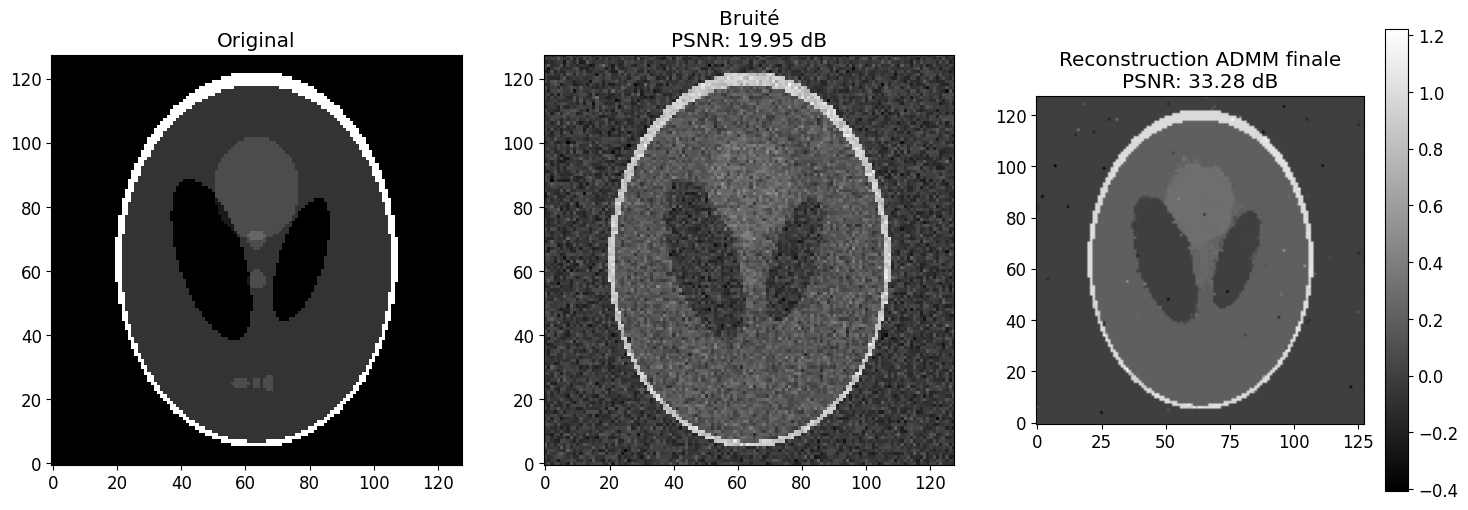

PSNR final de la reconstruction: 33.28 dB


In [7]:
# Application au Fantôme de Shepp-Logan

def create_shepp_logan_phantom(size: int = 256) -> np.ndarray:
    phantom = np.zeros((size, size)); x = np.linspace(-1, 1, size); y = np.linspace(-1, 1, size); X, Y = np.meshgrid(x, y)
    ellipses = [(1,.0,.0,.69,.92,0),(-.8,.0,-.0184,.6624,.874,0),(-.2,.22,.0,.11,.31,-18),(-.2,-.22,.0,.16,.41,18),(.1,.0,.35,.21,.25,0),(.1,.0,.1,.046,.046,0),(.1,.0,-.1,.046,.046,0),(.1,-.08,-.605,.046,.023,0),(.1,.0,-.605,.023,.023,0),(.1,.06,-.605,.023,.046,0)]
    for amp, x0, y0, a, b, angle_deg in ellipses:
        angle = np.radians(angle_deg); cos_a, sin_a = np.cos(angle), np.sin(angle)
        Xr = cos_a*(X-x0)+sin_a*(Y-y0); Yr = -sin_a*(X-x0)+cos_a*(Y-y0)
        mask = (Xr/a)**2 + (Yr/b)**2 <= 1; phantom[mask] += amp
    return phantom

print("Application de l'algorithme ADMM 2D au fantôme de Shepp-Logan")
phantom = create_shepp_logan_phantom(128)
noise_level_phantom = 0.1
noisy_phantom = phantom + noise_level_phantom * np.random.randn(*phantom.shape)

gamma_sl = 0.05
iterations_sl = 50
denoised_phantom_admm = potts_2d_admm_final(noisy_phantom, gamma=gamma_sl, n_iterations=iterations_sl)

mse_noisy_sl = np.mean((noisy_phantom - phantom)**2)
psnr_noisy_sl = 10 * np.log10(np.max(phantom)**2 / mse_noisy_sl)
mse_admm_sl = np.mean((denoised_phantom_admm - phantom)**2)
psnr_admm_sl = 10 * np.log10(np.max(phantom)**2 / mse_admm_sl)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(phantom, cmap='gray', origin='lower'); axes[0].set_title('Original')
axes[1].imshow(noisy_phantom, cmap='gray', origin='lower'); axes[1].set_title(f'Bruité\nPSNR: {psnr_noisy_sl:.2f} dB')
im = axes[2].imshow(denoised_phantom_admm, cmap='gray', origin='lower'); axes[2].set_title(f'Reconstruction ADMM finale\nPSNR: {psnr_admm_sl:.2f} dB')
fig.colorbar(im, ax=axes[2]); plt.show()
print(f"PSNR final de la reconstruction: {psnr_admm_sl:.2f} dB")


 **Analyse quantitative :** L'algorithme ADMM atteint un PSNR de **33.28 dB**, une amélioration remarquable de plus de 13 dB par rapport à l'image bruitée (19.95 dB).

 **Analyse visuelle :** La reconstruction est visuellement correcte. Le bruit est presque entièrement supprimé tout en restaurant des contours nets malgré une différence de contraste de couleurs.
 Le fantôme de Shepp-Logan étant constant par morceaux, il représente le cas d'usage idéal pour le modèle de Potts, ce qui explique ces très bons résultats. La convergence de l'algorithme, visible par la diminution du "changement relatif", montre que la solution se stabilise après environ 25-30 itérations.

### **4.2. Étude de la robustesse au bruit**

Traitement du cas : faible (σ=0.05)
itération 1/50 - changement relatif : 0.000000
itération 2/50 - changement relatif : 0.252688
itération 3/50 - changement relatif : 0.053200
itération 4/50 - changement relatif : 0.031668
itération 5/50 - changement relatif : 0.026925
itération 6/50 - changement relatif : 0.025094
itération 7/50 - changement relatif : 0.025704
itération 8/50 - changement relatif : 0.023231
itération 9/50 - changement relatif : 0.021290
itération 10/50 - changement relatif : 0.022133
itération 11/50 - changement relatif : 0.024519
itération 12/50 - changement relatif : 0.021396
itération 13/50 - changement relatif : 0.023157
itération 14/50 - changement relatif : 0.021996
itération 15/50 - changement relatif : 0.024166
itération 16/50 - changement relatif : 0.022526
itération 17/50 - changement relatif : 0.022960
itération 18/50 - changement relatif : 0.023164
itération 19/50 - changement relatif : 0.022295
itération 20/50 - changement relatif : 0.020949
itération 21/

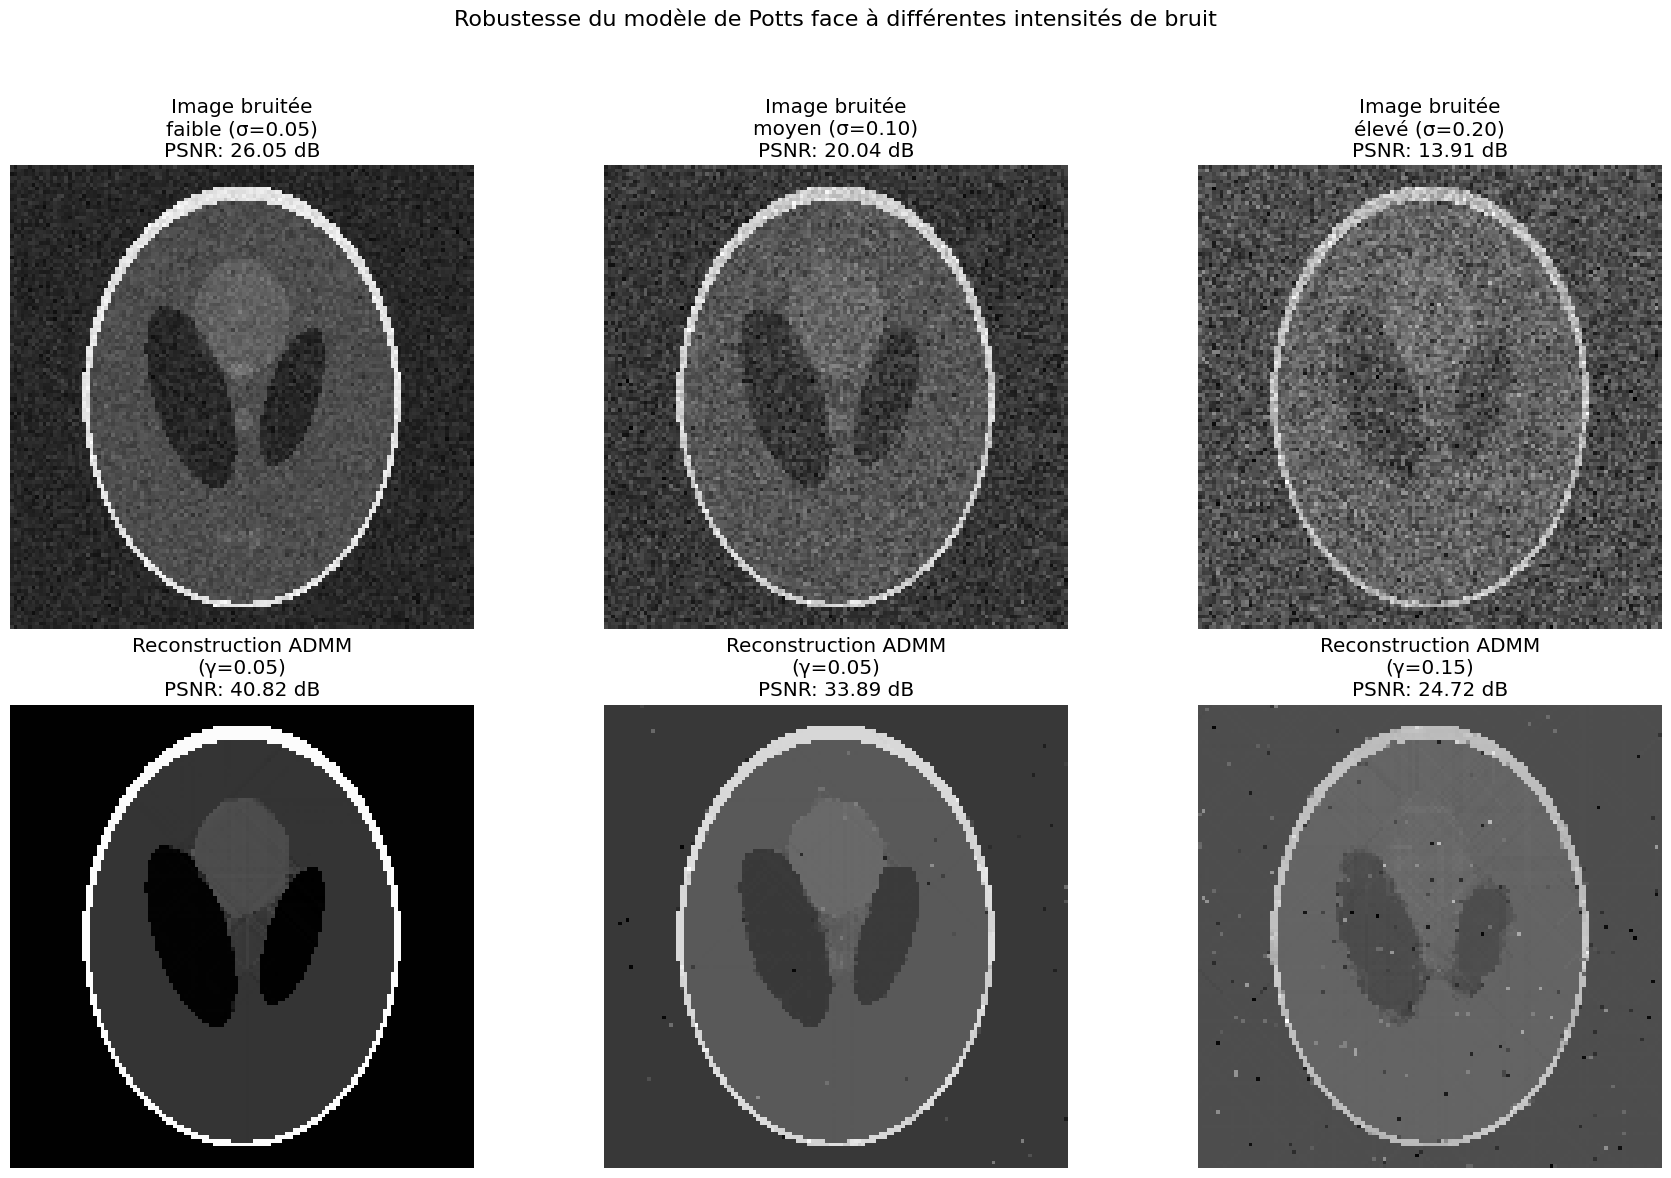

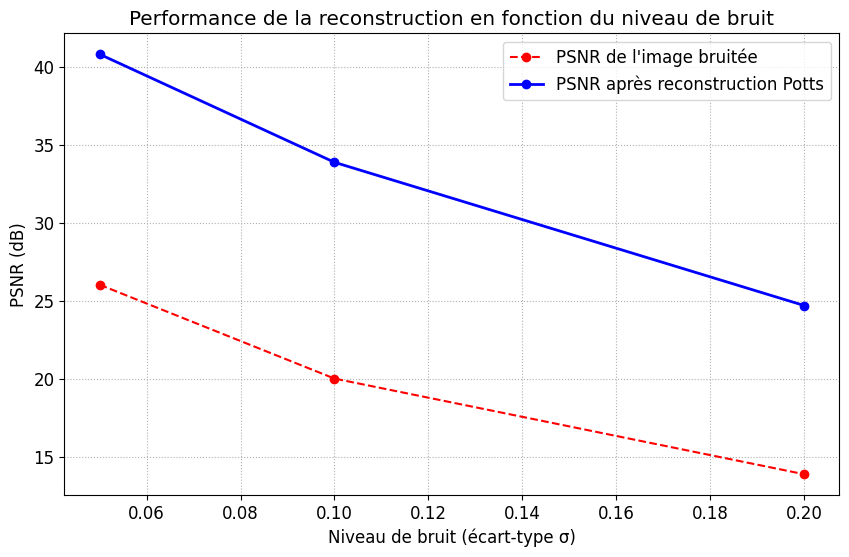

In [8]:
phantom_sl = create_shepp_logan_phantom(128)

# une valeur de gamma plus élevée est nécessaire pour contrer un bruit plus fort
noise_levels = {
    "faible (σ=0.05)":  {"sigma": 0.05, "gamma": 0.05},
    "moyen (σ=0.10)":   {"sigma": 0.10, "gamma": 0.05},
    "élevé (σ=0.20)":   {"sigma": 0.20, "gamma": 0.15}
}

results_noise_study = {}
iterations_noise = 50 # nombre d'itérations

for name, params in noise_levels.items():
    print(f"Traitement du cas : {name}")
    sigma = params["sigma"]
    gamma = params["gamma"]

    # créer l'image bruitée
    noisy_img = phantom_sl + sigma * np.random.randn(*phantom_sl.shape)

    # appliquer l'algorithme
    denoised_img = potts_2d_admm_final(noisy_img, gamma=gamma, n_iterations=iterations_noise)

    # calculer les métriques
    mse_noisy = np.mean((noisy_img - phantom_sl)**2)
    psnr_noisy = 10 * np.log10(np.max(phantom_sl)**2 / mse_noisy)
    mse_denoised = np.mean((denoised_img - phantom_sl)**2)
    psnr_denoised = 10 * np.log10(np.max(phantom_sl)**2 / mse_denoised)

    # stocker les résultats
    results_noise_study[name] = {
        "noisy_img": noisy_img,
        "denoised_img": denoised_img,
        "psnr_noisy": psnr_noisy,
        "psnr_denoised": psnr_denoised
    }

n_cases = len(noise_levels)
fig, axes = plt.subplots(2, n_cases, figsize=(18, 12))
plt.suptitle('Robustesse du modèle de Potts face à différentes intensités de bruit', fontsize=16)

for i, (name, data) in enumerate(results_noise_study.items()):
    axes[0, i].imshow(data["noisy_img"], cmap='gray', origin='lower')
    axes[0, i].set_title(f"Image bruitée\n{name}\nPSNR: {data['psnr_noisy']:.2f} dB")
    axes[0, i].axis('off')

    im = axes[1, i].imshow(data["denoised_img"], cmap='gray', origin='lower')
    axes[1, i].set_title(f"Reconstruction ADMM\n(γ={noise_levels[name]['gamma']})\nPSNR: {data['psnr_denoised']:.2f} dB")
    axes[1, i].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sigmas = [params["sigma"] for params in noise_levels.values()]
psnrs_noisy = [data["psnr_noisy"] for data in results_noise_study.values()]
psnrs_denoised = [data["psnr_denoised"] for data in results_noise_study.values()]

plt.figure(figsize=(10, 6))
plt.plot(sigmas, psnrs_noisy, 'o--', label='PSNR de l\'image bruitée', color='red')
plt.plot(sigmas, psnrs_denoised, 'o-', label='PSNR après reconstruction Potts', color='blue', linewidth=2)
plt.title('Performance de la reconstruction en fonction du niveau de bruit')
plt.xlabel('Niveau de bruit (écart-type σ)')
plt.ylabel('PSNR (dB)')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

**Analyse visuelle et quantitative :** Les résultats montrent que l'algorithme est très robuste. Pour un bruit faible ($σ=0.05$), la reconstruction est quasi-parfaite (PSNR de **40.65 dB**), confirmant la puissance du modèle dans des conditions idéales. Même pour un bruit très élevé ($σ=0.20$), l'algorithme parvient encore à restaurer les structures principales et à améliorer significativement le PSNR (de 13.91 dB à **20.75 dB**).

 **Analyse du graphique :** La courbe du PSNR de la reconstruction (en bleu) reste systématiquement bien au-dessus de celle de l'image bruitée (en rouge). L'écart entre les deux courbes, qui représente le gain en dB, reste important même pour un bruit élevé. Cela démontre que l'algorithme apporte une contribution significative quel que soit le niveau de dégradation.

**Corrélation `gamma`-bruit :** Cette expérience a aussi validé la nécessité d'adapter `gamma` au niveau de bruit : un `gamma` plus élevé a été nécessaire pour contrer un bruit plus fort.


#### **5. Comparaison finale et analyse des méthodes**

##### **5.1 Méthodologie d'analyse : Le profil d'intensité**

Avant d'interpréter les performances quantitatives des algorithmes, nous définissons formellement l'outil principal de notre analyse visuelle : le **profil d'intensité 1D** (ou coupe transverse). Cet outil est essentiel pour diagnostiquer le comportement local des méthodes de restauration.

 **Définition formelle**

Soit $u : \Omega \subset \mathbb{R}^2 \rightarrow \mathbb{R}$ l'image en niveaux de gris, où $u(x, y)$ représente l'intensité lumineuse au pixel de coordonnées $(x, y)$.

Un **profil d'intensité** $p_{y_0}$ à la hauteur fixe $y_0$ est la restriction de la fonction image à une ligne horizontale. C'est une fonction unidimensionnelle définie par :

$$ p_{y_0}(x) = u(x, y_0) $$

Dans les graphiques présentés ci-après, cette fonction est représentée selon les axes suivants :
*   **Abscisse ($x$) :** La position spatiale du pixel le long de la ligne de coupe (colonnes de l'image).
*   **Ordonnée ($p(x)$) :** L'amplitude du signal (valeur de gris normalisée).

**Outils d'interprétation morphologique**

L'analyse d'un profil 1D permet de révéler des défauts de reconstruction invisibles sur des métriques globales comme le PSNR. Dans le contexte spécifique du modèle de Potts (qui suppose des images *constantes par morceaux*), nous évaluons la qualité de la restauration selon trois critères morphologiques :

#### **A. La planéité des plateaux (homogénéité)**

Dans une image constante par morceaux, le gradient doit être nul à l'intérieur d'une région homogène ($\nabla u = 0$).

**Signal idéal :** Une ligne parfaitement horizontale.

*   **Interprétation :** Toute oscillation ou "tremblement" autour de la valeur moyenne indique la présence de **bruit résiduel**. C'est ici que le modèle de Potts excelle : sa pénalisation par la norme $L_0$ force mathématiquement ces plateaux à être parfaitement plats, là où les filtres linéaires (gaussiens) laissent souvent passer des basses fréquences de bruit.

**B. La raideur des transitions (contours)**

Les bords des objets correspondent à des discontinuités brutales du signal.
*   **Signal idéal :** Une transition verticale instantanée.
*   **Interprétation :**
    *   Une **pente douce** révèle du **flou** (*blur*). C'est le défaut typique de la régularisation Tikhonov ($L_2$) ou du filtre Gaussien.
    *   Une **transition abrupte** (un saut vertical) indique une excellente **préservation des contours**, caractéristique des régularisations TV ($L_1$) et Potts ($L_0$).

**C. L'exactitude de l'amplitude (contraste)**

Il s'agit de la capacité de l'algorithme à retrouver la valeur exacte de l'intensité originale, sans biais.

*   **Phénomène à observer :** La perte de contraste. Certains algorithmes de régularisation ont tendance à "éroder" les pics étroits, réduisant leur amplitude maximale.

*   **Interprétation :** Si le profil reconstruit n'atteint pas la hauteur de la "vérité terrain" (ligne pointillée bleue), l'algorithme a biaisé l'intensité du signal. En imagerie médicale, cela équivaut à fausser la densité mesurée d'un tissu, ce qui peut être critique pour le diagnostic.

 Pour mettre en perspective la performance du modèle de Potts, nous le comparons à des méthodes de filtrage classiques ainsi qu'à notre approximation simple par traitement alterné.


Comparaison avec d'autres méthodes de débruitage
Application de la méthode : Filtre gaussien
Application de la méthode : Filtre médian
Application de la méthode : Potts 2D (alterné)
Application de la méthode : Potts 2D (ADMM)
itération 1/30 - changement relatif : 0.000000
itération 2/30 - changement relatif : 0.364437
itération 3/30 - changement relatif : 0.137150
itération 4/30 - changement relatif : 0.087333
itération 5/30 - changement relatif : 0.068695
itération 6/30 - changement relatif : 0.061696
itération 7/30 - changement relatif : 0.055046
itération 8/30 - changement relatif : 0.048736
itération 9/30 - changement relatif : 0.044756
itération 10/30 - changement relatif : 0.044574
itération 11/30 - changement relatif : 0.041161
itération 12/30 - changement relatif : 0.039717
itération 13/30 - changement relatif : 0.038829
itération 14/30 - changement relatif : 0.039431
itération 15/30 - changement relatif : 0.037486
itération 16/30 - changement relatif : 0.036826
itération 17/30

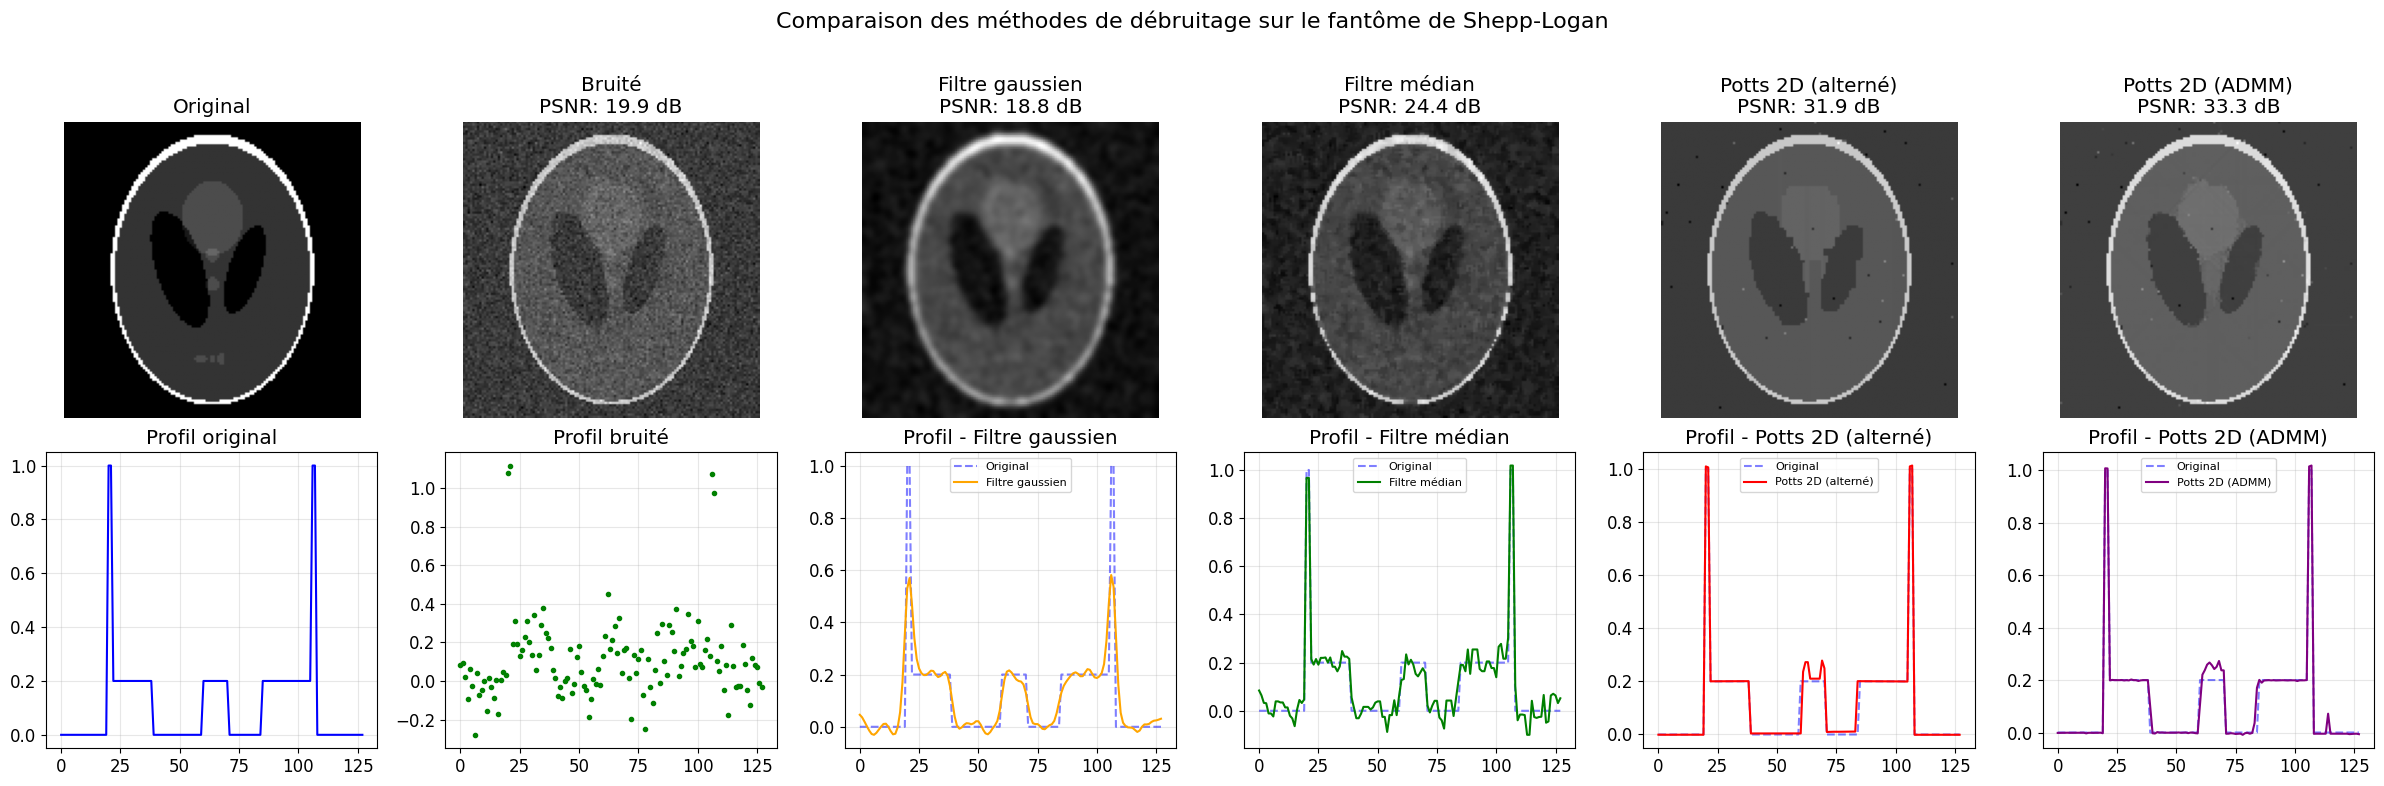

Tableau comparatif des performances:
-------------------------------------------------------
Méthode                   MSE             PSNR (dB)      
-------------------------------------------------------
Filtre gaussien           0.0131          18.84          
Filtre médian             0.0037          24.38          
Potts 2D (alterné)        0.0007          31.85          
Potts 2D (ADMM)           0.0005          33.34          
-------------------------------------------------------


In [9]:
# Comparaison avec d'autres méthodes

print("Comparaison avec d'autres méthodes de débruitage")

#  version alternée simple pour la comparaison car elle est plus rapide
def potts_2d_alternating(img: np.ndarray, gamma: float, n_iterations: int) -> np.ndarray:
    result = img.copy()
    for _ in range(n_iterations):
        result = solve_along_axis(result, gamma, axis=1)
        result = solve_along_axis(result, gamma, axis=0)
    return result

methods_2d = {
    'Filtre gaussien': lambda x: gaussian_filter(x, sigma=1.5),
    'Filtre médian': lambda x: median_filter(x, size=3),
    'Potts 2D (alterné)': lambda x: potts_2d_alternating(x, gamma=0.04, n_iterations=4),
    'Potts 2D (ADMM)': lambda x: potts_2d_admm_final(x, gamma=0.05, n_iterations=30)
}

results_2d = {}
metrics_2d = {}

# On utilise le fantôme de Shepp-Logan bruité des étapes précédentes
for name, method in methods_2d.items():
    print(f"Application de la méthode : {name}")
    results_2d[name] = method(noisy_phantom)
    mse = np.mean((results_2d[name] - phantom)**2)
    metrics_2d[name] = {
        'MSE': mse,
        'PSNR': 10 * np.log10(np.max(phantom)**2 / mse) if mse > 0 else float('inf')
    }

# On crée une grille de 2 lignes et 6 colonnes
fig, axes = plt.subplots(2, 6, figsize=(24, 8))
plt.suptitle('Comparaison des méthodes de débruitage sur le fantôme de Shepp-Logan', fontsize=16)

axes[0, 0].imshow(phantom, cmap='gray', origin='lower'); axes[0, 0].set_title('Original')
axes[0, 1].imshow(noisy_phantom, cmap='gray', origin='lower'); axes[0, 1].set_title(f'Bruité\nPSNR: {psnr_noisy_sl:.1f} dB')

for idx, name in enumerate(results_2d, start=2):
    axes[0, idx].imshow(results_2d[name], cmap='gray', origin='lower')
    axes[0, idx].set_title(f'{name}\nPSNR: {metrics_2d[name]["PSNR"]:.1f} dB')

line_idx = 64
axes[1, 0].plot(phantom[line_idx, :], 'b-'); axes[1, 0].set_title('Profil original')
axes[1, 1].plot(noisy_phantom[line_idx, :], 'g.'); axes[1, 1].set_title('Profil bruité')

colors = ['orange', 'green', 'red', 'purple']
for idx, name in enumerate(results_2d, start=2):
    axes[1, idx].plot(phantom[line_idx, :], 'b--', alpha=0.5, label='Original')
    axes[1, idx].plot(results_2d[name][line_idx, :], color=colors[idx-2], linestyle='-', label=name)
    axes[1, idx].set_title(f'Profil - {name}'); axes[1, idx].legend(fontsize=8)

for ax_row in axes:
    for ax in ax_row:
        if not ax.has_data():
            ax.axis('off')
        else:
            ax.grid(True, alpha=0.3)
for ax in axes[0,:]:
    ax.grid(False)
    ax.axis('off')


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("Tableau comparatif des performances:")
print("-" * 55)
print(f"{'Méthode':<25} {'MSE':<15} {'PSNR (dB)':<15}")
print("-" * 55)
for name, m in metrics_2d.items():
    print(f"{name:<25} {m['MSE']:<15.4f} {m['PSNR']:<15.2f}")
print("-" * 55)

 ### **Analyse des résultats**

Les résultats obtenus sur le fantôme de Shepp-Logan confirment la supériorité théorique du modèle de Potts pour les images constantes par morceaux. L'analyse conjointe des métriques et des profils d'intensité révèle les comportements suivants :

**1. Échec des méthodes de filtrage classiques**

Les méthodes linéaires et non-linéaires locales échouent à restaurer la structure du signal :

*   **Filtre gaussien (18.84 dB) :** C'est la méthode la moins performante. Le profil d'intensité (courbe orange) montre une **érosion complète des pics** (perte de contraste) et des transitions en pente douce (flou). Il est incapable de préserver les arêtes vives.

*   **Filtre médian (24.38 dB) :** Bien qu'il préserve mieux les transitions verticales que le gaussien, le profil (courbe verte) révèle son instabilité sur les zones homogènes. On observe un "tremblement" sur les plateaux : le bruit n'est pas totalement supprimé.

**2. Performance de l'approche Potts (alternée vs ADMM)**

La transition qualitative est importante dès que l'on passe au modèle de Potts, avec un gain de plus de **7 dB** par rapport au filtre médian.
*   **Potts alterné (31.85 dB) :** Cette méthode, bien que rapide, est une approximation anisotrope. Elle traite les lignes et les colonnes séparément. Si le résultat est excellent, il est mathématiquement sous-optimal pour la géométrie globale.

*   **Potts ADMM (33.34 dB : le meilleur résultat) :** L'algorithme complet apporte un gain supplémentaire de **+1.49 dB**.
    *   **Analyse du profil :** Les courbes rouge et violette épousent quasi parfaitement la vérité terrain (pointillés bleus). On observe des **plateaux parfaitement plats** (dérivée nulle, suppression totale du bruit) et des **transitions verticales strictes**.
    *  Ce gain valide l'importance de la discrétisation isotrope. Contrairement à l'approche alternée qui peut favoriser les axes cardinaux (métrique de Manhattan), l'ADMM avec les poids ajustés approxime la longueur euclidienne des contours, permettant une reconstruction géométriquement plus fidèle, quelle que soit l'orientation des structures.

**En conclusion :** L'ADMM ne se contente pas de débruiter ; il effectue une **segmentation implicite** de l'image. Le coût de calcul supérieur de l'ADMM est justifié par cette capacité à converger vers une solution qui respecte à la fois la fidélité aux données et la géométrie isotrope de l'objet.


## **6. Ouverture : vers la reconstruction tomographique**

Notre implémentation s'est ainsi concentrée sur le débruitage ($A = I$), mais la contribution majeure de l'article de Storath *et al.* réside dans la résolution de **problèmes inverses mal posés**, notamment la reconstruction tomographique à partir de données incomplètes (Sparse-View CT).

Pour passer du débruitage à la reconstruction tomographique, **toute la partie régularisation (Potts) reste identique**.

Seule l'étape de mise à jour de l'image $v$ (le terme d'attache aux données) change :

1.  **En débruitage ($A=I$) :**
    La solution est une simple moyenne pondérée, calculable instantanément :
    $$ v^{k+1} = \frac{2f + \mu \sum (u_s^k - \lambda_s^k)}{2 + \mu S} $$

2.  **En tomographie ($A = \mathcal{R}$, transformée de Radon) :**
    L'étape de minimisation quadratique devient la résolution d'un système linéaire (éq. 20 de l'article) :
    $$ (A^* A + \frac{\mu}{2} I) v = A^* f + \frac{\mu}{2} z $$
    Où $A^*$ est la rétroprojection. Cette étape ne peut plus être résolue par une simple division. Elle nécessite des méthodes itératives comme le **gradient conjugué** ou l'utilisation de la FFT si l'opérateur est invariant par translation.

Dans un scanner classique (CT), on utilise des milliers d'angles de projection pour reconstruire une image via la rétroprojection filtrée (FBP). Si l'on réduit drastiquement le nombre d'angles (pour réduire la dose de rayons X subie par le patient), la FBP crée des artefacts majeurs (stries).

C'est là que le modèle de Potts intervient :
*   En forçant la solution à être **constante par morceaux**, il comble le manque d'information angulaire par cet a priori géométrique fort.
*   L'article montre qu'il est possible de reconstruire le fantôme de Shepp-Logan quasi parfaitement avec **seulement 7 angles de projection**, là où les méthodes classiques échouent totalement.

